In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load
df = pd.read_excel('sales_dataset.xlsx')

# Inspect
print(df.shape)       # (1194, 12)
print(df.dtypes)
print(df.isnull().sum())   # Should be all zeros
print(df.describe())

# Preview
df.head()

(1194, 12)
Order ID                object
Amount                   int64
Profit                   int64
Quantity                 int64
Category                object
Sub-Category            object
PaymentMode             object
Order Date      datetime64[ns]
CustomerName            object
State                   object
City                    object
Year-Month              object
dtype: object
Order ID        0
Amount          0
Profit          0
Quantity        0
Category        0
Sub-Category    0
PaymentMode     0
Order Date      0
CustomerName    0
State           0
City            0
Year-Month      0
dtype: int64
            Amount       Profit     Quantity                     Order Date
count  1194.000000  1194.000000  1194.000000                           1194
mean   5178.089615  1348.992462    10.674204  2022-10-03 21:49:44.924623104
min     508.000000    50.000000     1.000000            2020-03-22 00:00:00
25%    2799.000000   410.000000     6.000000            2021-09-06 00:

,Order ID,Amount,Profit,Quantity,Category,Sub-Category,PaymentMode,Order Date,CustomerName,State,City,Year-Month
0,B-26776,9726,1275,5,Electronics,Electronic Games,UPI,2023-06-27,David Padilla,Florida,Miami,2023-06
1,B-26776,9726,1275,5,Electronics,Electronic Games,UPI,2024-12-27,Connor Morgan,Illinois,Chicago,2024-12
2,B-26776,9726,1275,5,Electronics,Electronic Games,UPI,2021-07-25,Robert Stone,New York,Buffalo,2021-07
3,B-26776,4975,1330,14,Electronics,Printers,UPI,2023-06-27,David Padilla,Florida,Miami,2023-06
4,B-26776,4975,1330,14,Electronics,Printers,UPI,2024-12-27,Connor Morgan,Illinois,Chicago,2024-12


In [3]:
# Clean column names (remove spaces)
df.columns = df.columns.str.replace(' ', '_').str.replace('-', '_')
# Now Sub-Category becomes Sub_Category

# Add Profit Margin column
df['Profit_Margin_Pct'] = (df['Profit'] / df['Amount'] * 100).round(2)

# Parse Order Date properly
df['Order_Date'] = pd.to_datetime(df['Order_Date'])
df['Month'] = df['Order_Date'].dt.month
df['Year'] = df['Order_Date'].dt.year

# Verify
print(df[['Amount','Profit','Profit_Margin_Pct']].describe())

            Amount       Profit  Profit_Margin_Pct
count  1194.000000  1194.000000        1194.000000
mean   5178.089615  1348.992462          26.057018
std    2804.921955  1117.992573          14.051863
min     508.000000    50.000000           0.780000
25%    2799.000000   410.000000          14.067500
50%    5152.000000  1014.000000          25.575000
75%    7626.000000  2035.000000          38.190000
max    9992.000000  4930.000000          50.000000


                 Revenue  Profit  Orders
Category                                
Office Supplies  2089510  551575     399
Electronics      2054456  518580     388
Furniture        2038673  540542     407


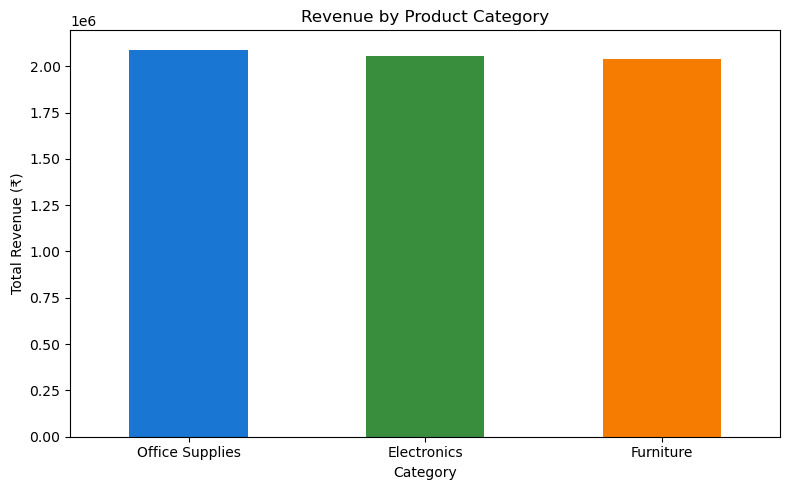

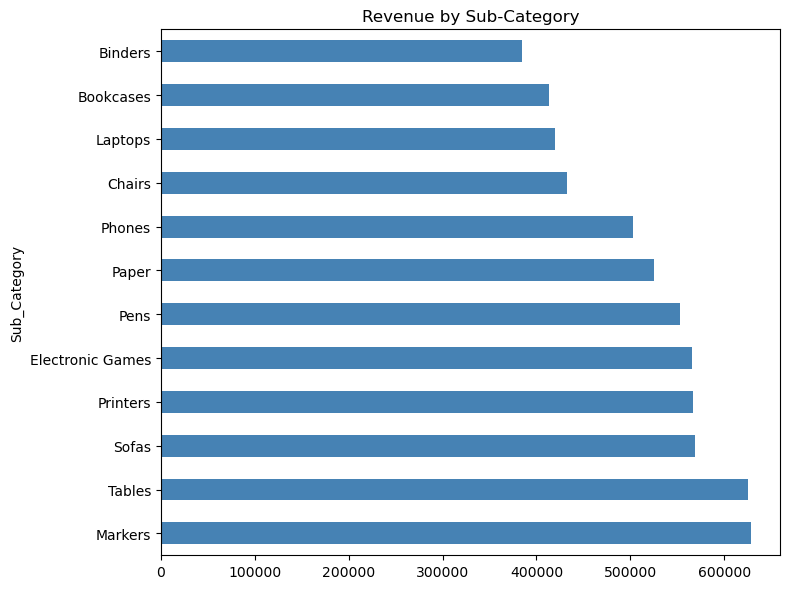

In [4]:
# Revenue by Category
cat_rev = df.groupby('Category').agg(
    Revenue=('Amount','sum'),
    Profit=('Profit','sum'),
    Orders=('Order_ID','count')
).sort_values('Revenue', ascending=False)
print(cat_rev)

# Bar chart — Revenue by Category
plt.figure(figsize=(8,5))
cat_rev['Revenue'].plot(kind='bar', color=['#1976D2','#388E3C','#F57C00'])
plt.title('Revenue by Product Category')
plt.ylabel('Total Revenue (₹)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('revenue_by_category.png', dpi=150)
plt.show()

# Sub-category performance
subcat = df.groupby('Sub_Category')['Amount'].sum().sort_values(ascending=False)
subcat.plot(kind='barh', figsize=(8,6), color='steelblue')
plt.title('Revenue by Sub-Category')
plt.tight_layout()
plt.savefig('revenue_by_subcategory.png', dpi=150)
plt.show()

            Revenue  Orders  Avg_Order_Value
State                                       
New York    1130048     226      5000.212389
Florida     1091174     200      5455.870000
California  1086436     218      4983.651376
Texas       1011475     189      5351.719577
Illinois     978738     181      5407.392265
Ohio         884768     180      4915.377778
                    Total_Spent  Orders  Profit
CustomerName                                   
Cory Evans                28557       4    7790
Emily Ellison             27352       3    6848
George Foster             27352       3    6848
Nicholas Anderson         27352       3    6848
Katherine Williams        25121       3    5972
Jacqueline Harris         24433       4    6535
Randy Johnson             24295       3    5858
Tammy Bell                23895       3    6388
Brian Green               23737       3    4623
Zachary Perez             23737       3    4623


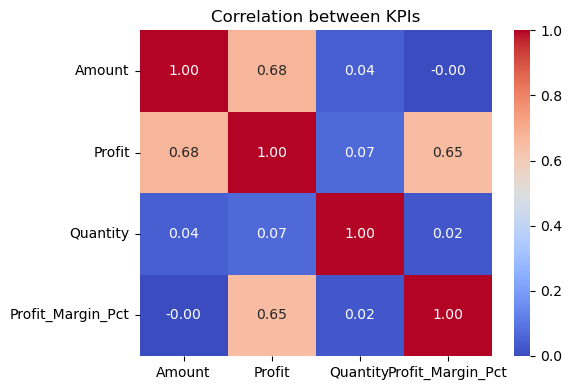

In [5]:
    # Revenue by State
state_rev = df.groupby('State').agg(
    Revenue=('Amount','sum'),
    Orders=('Order_ID','count'),
    Avg_Order_Value=('Amount','mean')
).sort_values('Revenue', ascending=False)
print(state_rev)

# Top 10 customers
top_customers = df.groupby('CustomerName').agg(
    Total_Spent=('Amount','sum'),
    Orders=('Order_ID','count'),
    Profit=('Profit','sum')
).sort_values('Total_Spent', ascending=False).head(10)
print(top_customers)

# Correlation heatmap
plt.figure(figsize=(6,4))
sns.heatmap(
  df[['Amount','Profit','Quantity','Profit_Margin_Pct']].corr(),
  annot=True, cmap='coolwarm', fmt='.2f'
)
plt.title('Correlation between KPIs')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()

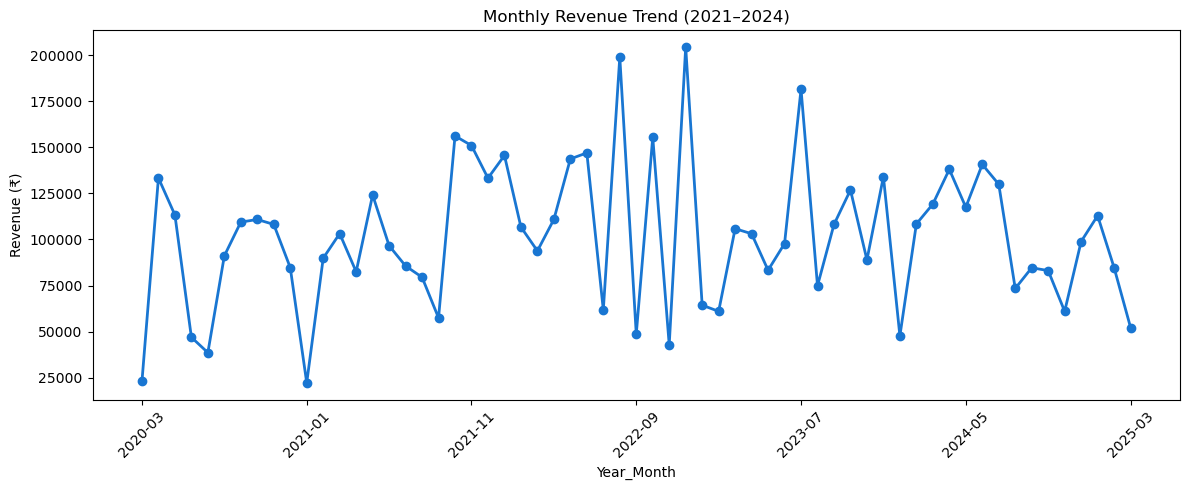

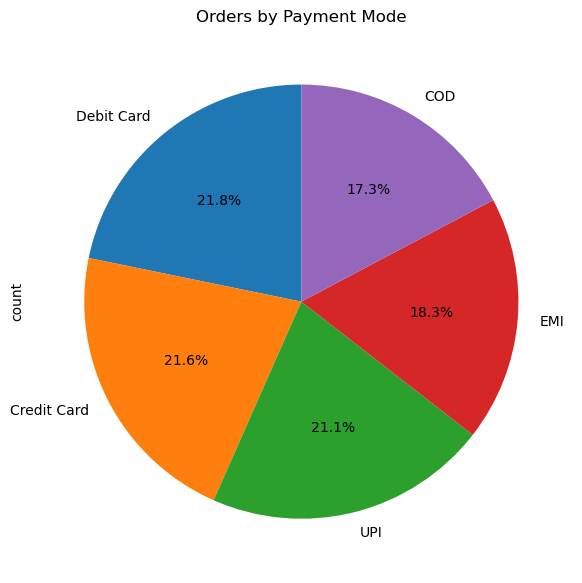

In [6]:
 #Monthly Revenue Trend
monthly = df.groupby('Year_Month')['Amount'].sum()

plt.figure(figsize=(12,5))
monthly.plot(kind='line', marker='o', color='#1976D2', linewidth=2)
plt.title('Monthly Revenue Trend (2021–2024)')
plt.ylabel('Revenue (₹)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('monthly_trend.png', dpi=150)
plt.show()

# Payment mode distribution
payment = df['PaymentMode'].value_counts()
plt.figure(figsize=(6,6))
payment.plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.title('Orders by Payment Mode')
plt.tight_layout()
plt.savefig('payment_distribution.png', dpi=150)
plt.show()

Key Insights
📈 Revenue shows an overall upward trend with some seasonal peaks.
🥧 Customers prefer one payment mode over others.
📊 A few product categories generate the highest revenue.
🏆 The top 5 sub-categories contribute significantly to total sales.
💡 Sales insights can help improve inventory, marketing, and business decisions.
Conclusion

The analysis highlights revenue trends, customer payment preferences, and top-performing products, providing valuable insights for better business planning and decision-making.